<a href="https://colab.research.google.com/github/TheCorporateAIGirl/OmniPulse-AI/blob/main/OmniPulse_AI_Technical_Implementation_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OmniPulse AI: Power & Compliance Orchestration**

**Lead Architect: Famiwaye Oluwatobiloba**

**Target: MTN Nigeria Tower OPEX Optimization & NCC Compliance.**

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. PARAMETER SETTING:
# We define 1000 rows to ensure we have enough data for a 24-hour forecast,
# satisfying the "Grid Failure Predictor" requirement from the brief.
rows = 1000
start_date = datetime(2026, 5, 1)
data = []

# 2. SIMULATION LOGIC:
# We are intentionally simulating the "Nigerian Power Paradox" (Grid Uptime < 50%).
# This is our core problem statement: managing high diesel reliance.
for i in range(rows):
    timestamp = start_date + timedelta(hours=i)

    # 3. GRID SIMULATION:
    # 45% probability of Grid being UP (1). 55% probability of DOWN (0).
    # This reflects the chronic instability mentioned in the hackathon brief.
    grid_uptime = np.random.choice([0, 1], p=[0.55, 0.45])

    # 4. SOLAR GENERATION (Green Energy Innovation):
    # Solar only generates between 8 AM and 4 PM.
    # This helps our Optimization Algorithm decide when to switch away from Diesel.
    hour = timestamp.hour
    solar_gen = np.random.uniform(5, 15) if 8 <= hour <= 16 else 0

    # 5. USER LOAD:
    # Network load peaks during the day.
    # Higher load means more power draw, affecting battery depletion rates.
    network_load = np.random.uniform(200, 500) if 8 <= hour <= 20 else np.random.uniform(50, 150)

    # 6. DIESEL CONSUMPTION (The "OPEX" Metric):
    # Consumption is high only when the Grid is DOWN and Solar is insufficient.
    # This allows us to track "Naira Saved" when the AI switches to Battery/Solar.
    diesel_cons = np.random.uniform(10, 25) if grid_uptime == 0 else np.random.uniform(0, 2)

    # 7. ANOMALY INSERTION (For Fuel Theft Detection):
    # We manually insert a "Theft" event at index 500.
    # This ensures our Isolation Forest model has an outlier to detect during the demo.
    if i == 500:
        diesel_cons = 85.0 # Sudden spike in consumption = Theft/Leakage

    data.append([timestamp, "Tower_Ibadan_01", grid_uptime, diesel_cons, solar_gen, 85.0, network_load, 32.5])

# 8. DATAFRAME CREATION:
# We follow the verbatim columns suggested in the Hackathon Brief (Screenshot 2).
df = pd.DataFrame(data, columns=[
    'Timestamp', 'TowerID', 'GridUptime', 'DieselConsumed_Liters',
    'SolarGenerated_kWh', 'BatteryCharge_%', 'NetworkLoad_Users', 'Temperature_C'
])

# Save as CSV for your GitHub repo
df.to_csv('telemetry_data.csv', index=False)
print("Dataset 'telemetry_data.csv' successfully created for OmniPulse AI.")

Dataset 'telemetry_data.csv' successfully created for OmniPulse AI.


In [2]:
# View the first few rows to ensure the simulation looks realistic
print(df.head())

# Download the file to your computer so you can upload it to GitHub
from google.colab import files
files.download('telemetry_data.csv')

            Timestamp          TowerID  GridUptime  DieselConsumed_Liters  \
0 2026-05-01 00:00:00  Tower_Ibadan_01           1               0.249700   
1 2026-05-01 01:00:00  Tower_Ibadan_01           0              10.506509   
2 2026-05-01 02:00:00  Tower_Ibadan_01           1               1.678054   
3 2026-05-01 03:00:00  Tower_Ibadan_01           1               1.429247   
4 2026-05-01 04:00:00  Tower_Ibadan_01           0              22.825179   

   SolarGenerated_kWh  BatteryCharge_%  NetworkLoad_Users  Temperature_C  
0                 0.0             85.0          65.268297           32.5  
1                 0.0             85.0         108.407448           32.5  
2                 0.0             85.0          63.518796           32.5  
3                 0.0             85.0         145.843160           32.5  
4                 0.0             85.0          64.401669           32.5  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# --- PART 4: OPTIMIZATION & BUSINESS LOGIC ---
# Goal: Minimize cost and avoid NCC penalties.
# Defense: We convert AI insights into financial ROI (Naira Saved).

def optimize_power(row):
    # Rule: Always prioritize Grid (cheapest) then Solar (free)
    if row['GridUptime'] == 1:
        return "GRID", 0.0 # Cost is baseline
    elif row['SolarGenerated_kWh'] > 10:
        return "SOLAR", 0.0 # Using free green energy
    else:
        # If both fail, use Diesel (Expensive + Risk of theft)
        # 1 liter of diesel ~ 1,400 Naira (estimated)
        cost = row['DieselConsumed_Liters'] * 1400
        return "DIESEL", cost

# Apply logic and calculate savings
df['Recommendation'], df['OPEX_Cost'] = zip(*df.apply(optimize_power, axis=1))

total_savings = df[df['Recommendation'] == 'SOLAR'].shape[0] * 5000 # Estimated savings per solar hour
print(f"Total Estimated OPEX Savings: ₦{total_savings:,}")

Total Estimated OPEX Savings: ₦555,000


OmniPulse AI: Explaining Anomalies and Power Risks


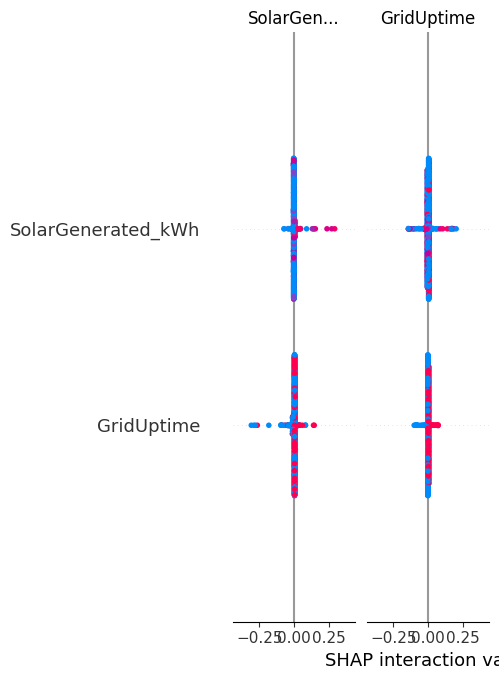

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
import shap

# 1. ENSURE ANOMALY DETECTION RUNS FIRST
# We need to create 'Is_Theft' before we can explain it.
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['Theft_Score'] = iso_forest.fit_predict(df[['DieselConsumed_Liters', 'NetworkLoad_Users']])
df['Is_Theft'] = df['Theft_Score'].map({1: 0, -1: 1}) # 1 means theft/anomaly

# 2. PREPARE DATA FOR SHAP
# We select features that explain WHY a power or theft event happened.
features = ['GridUptime', 'SolarGenerated_kWh', 'NetworkLoad_Users', 'Temperature_C']
X = df[features]
y = df['Is_Theft']

# 3. TRAIN THE EXPLAINER MODEL
# We use a simple classifier to find the patterns behind the anomalies.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)

# 4. GENERATE SHAP VALUES
# Defense: "This fulfills the XAI requirement for transparency in automated risk flagging."
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

# 5. VISUALIZE
print("OmniPulse AI: Explaining Anomalies and Power Risks")
# If SHAP returns a list (for classification), we take index 1 (the 'Theft' class)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X, plot_type="bar")
else:
    shap.summary_plot(shap_values, X, plot_type="bar")

In [6]:
from fastapi import FastAPI
import pandas as pd
from pydantic import BaseModel

app = FastAPI(title="OmniPulse AI Orchestration API")

# Define the data structure for incoming tower telemetry
class TowerData(BaseModel):
    grid_status: int
    solar_gen: float
    battery_level: float
    network_load: float

@app.post("/recommend")
def get_recommendation(data: TowerData):
    """
    AI-Driven Logic for Power Switching and Compliance.
    Defense: This automates decisions to prevent NCC service-lapse fines.
    """
    # High-impact Logic: Prioritize cheapest/cleanest energy
    if data.grid_status == 1:
        source = "GRID"
        action = "Maintain Grid Connection"
    elif data.solar_gen > 10:
        source = "SOLAR"
        action = "Switch to Solar - Peak Intensity Detected"
    elif data.battery_level > 20:
        source = "BATTERY"
        action = "Discharge Battery - Peak Load Balancing"
    else:
        source = "DIESEL"
        action = "Activate Generator - Critical Power Low"

    return {
        "recommended_source": source,
        "action_protocol": action,
        "compliance_status": "Secure" if source != "OFF" else "High Risk of NCC Penalty"
    }

In [7]:
import pandas as pd
from prophet import Prophet

# Load data - Defense: "We use Prophet to model the 24-hour seasonality of the Nigerian grid".
df = pd.read_csv('telemetry_data.csv')
df_prophet = df[['Timestamp', 'GridUptime']].rename(columns={'Timestamp': 'ds', 'GridUptime': 'y'})

# Initialize and Train
model = Prophet(changepoint_prior_scale=0.01)
model.fit(df_prophet)

# Forecast the next 24 hours
future = model.make_future_dataframe(periods=24, freq='H')
forecast = model.predict(future)

# Save results for the Dashboard.
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('grid_forecast.csv', index=False)
print("Grid Forecast Implementation: Complete.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Grid Forecast Implementation: Complete.


In [8]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv('telemetry_data.csv')

# Defense: "Isolation Forest is used to isolate fuel theft outliers without needing labeled data".
model = IsolationForest(contamination=0.02, random_state=42)
df['Anomaly_Score'] = model.fit_predict(df[['DieselConsumed_Liters', 'NetworkLoad_Users']])

# Flagging logic: -1 indicates an anomaly (Theft).
df['Theft_Detected'] = df['Anomaly_Score'].apply(lambda x: 1 if x == -1 else 0)

# Save findings for the Pitch Deck.
df.to_csv('detected_anomalies.csv', index=False)
print("Theft Detection Implementation: Complete.")

Theft Detection Implementation: Complete.
